In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# optional for time series
import datetime as dt

In [10]:
inflation = pd.read_excel("kz_inflation_from_2016_to_2026.xlsx")
oil = pd.read_excel("oil_from_2015_to_2026.xlsx")
fx = pd.read_excel("usdkzt_from_2016_to_2026.xlsx")

In [ ]:
# inflation.head()
# oil.head()
# fx.head()

def clean_bloomberg(df, value_name):
    df = df.copy()    
    df.columns = ["Date", value_name]
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    return df

inflation = clean_bloomberg(inflation, "inflation")
# oil = clean_bloomberg(oil, "oil_price")
fx = clean_bloomberg(fx, "usdkzt")

In [ ]:
oil = oil.copy()
oil["Date"] = pd.to_datetime(oil["Date"])
oil = oil[["Date", "Last Price"]]
oil = oil.rename(columns={"Last Price": "oil_price"})
oil = oil.sort_values("Date")
# oil.head()

,Date,oil_price
135,2014-12-31,57.33
134,2015-01-30,52.99
133,2015-02-27,62.58
132,2015-03-31,55.11
131,2015-04-30,66.78


In [17]:
df = inflation.merge(oil, on="Date", how="inner")
df = df.merge(fx, on="Date", how="inner")

df.head()

,Date,inflation,oil_price,usdkzt
0,2016-03-31,15.7,39.60,344.59
1,2016-05-31,16.7,49.69,336.10
2,2016-06-30,17.3,49.68,339.18
3,2016-08-31,17.6,47.04,340.50
4,2016-09-30,16.6,49.06,335.84


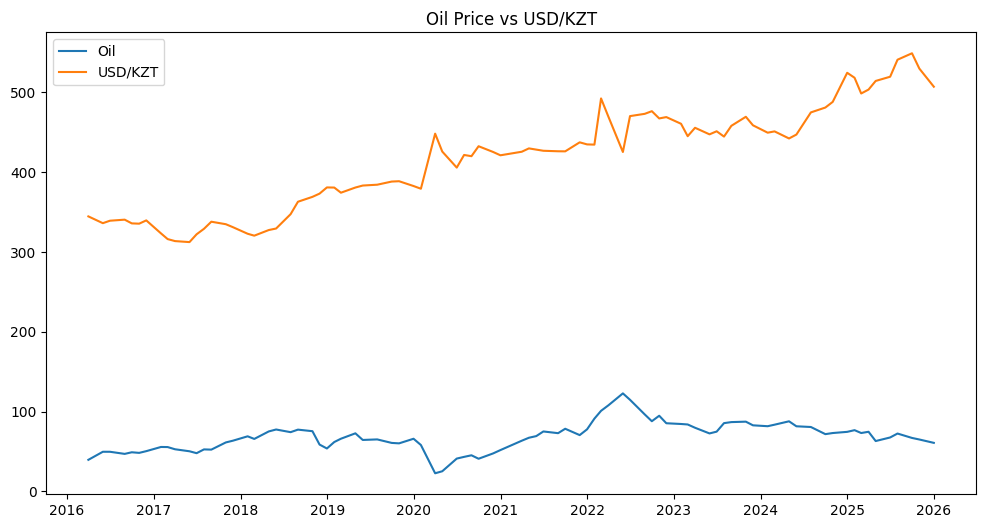

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["oil_price"], label="Oil")
plt.plot(df["Date"], df["usdkzt"], label="USD/KZT")
plt.legend()
plt.title("Oil Price vs USD/KZT")
plt.show()

- Oil: volatile (big drop in 2020, spike in 2022)
- USD/KZT: clear upward trend (tenge weakening)

-> Even when oil recovers, KZT does not fully strengthen back

In [19]:
df[["inflation", "oil_price", "usdkzt"]].corr()

,inflation,oil_price,usdkzt
inflation,1.000000,0.325421,0.319184
oil_price,0.325421,1.000000,0.438853
usdkzt,0.319184,0.438853,1.000000


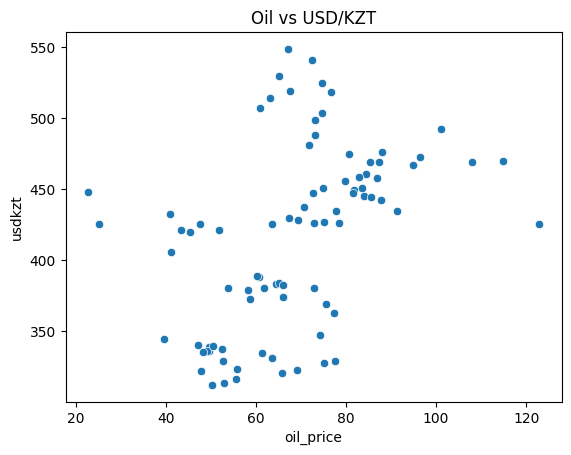

In [20]:
sns.scatterplot(data=df, x="oil_price", y="usdkzt")
plt.title("Oil vs USD/KZT")
plt.show()

We assume that Higher oil -> stronger KZT -> lower USD/KZT.

But in reality got weak / noisy positive relationship

In [21]:
df["oil_return"] = df["oil_price"].pct_change()
df["fx_return"] = df["usdkzt"].pct_change()
df["inflation_change"] = df["inflation"].diff()

In [22]:
df["oil_lag1"] = df["oil_price"].shift(1)
df["oil_lag3"] = df["oil_price"].shift(3)

In [24]:
import statsmodels.api as sm

X = df[["oil_price"]].dropna()
y = df.loc[X.index, "usdkzt"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 usdkzt   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     19.80
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.65e-05
Time:                        19:08:11   Log-Likelihood:                -464.53
No. Observations:                  85   AIC:                             933.1
Df Residuals:                      83   BIC:                             937.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        309.8648     24.795     12.497      0.0

In [25]:
df["oil_return"] = df["oil_price"].pct_change()
df["fx_return"] = df["usdkzt"].pct_change()

df = df.dropna()


import statsmodels.api as sm

X = df[["oil_return"]]
y = df["fx_return"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              fx_return   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     19.54
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           3.06e-05
Time:                        19:11:21   Log-Likelihood:                 161.70
No. Observations:                  82   AIC:                            -319.4
Df Residuals:                      80   BIC:                            -314.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0071      0.004      1.885      0.0

Oil ↑ → USD/KZT ↓
- Transforming data into returns revealed the true inverse relationship between oil prices and the Kazakh tenge.
- Changes in oil prices have a statistically significant negative effect on exchange rate movements. [Coefficient: -0.129; p-value: < 0.001]
- Oil explains about 20% of exchange rate fluctuations, indicating that while important, it is not the sole driver of currency movements.
- Using returns eliminates spurious regression and produces a statistically reliable model. [Durbin-Watson: ~2.14, no strong autocorrelation]

The Kazakh tenge is partially oil-driven, but the relationship is not strong enough to fully explain exchange rate movements. Oil shocks do impact FX, but other macroeconomic and policy factors play a significant role.